#                       STK-IN1050 Statistikk for informatikere, V26
###                                                        Obligatorisk innlevering 2 av 4

**Student:** Luka Simic


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

### a) Plott et histogram av temp. Beskriv hva du ser fra histogrammet.

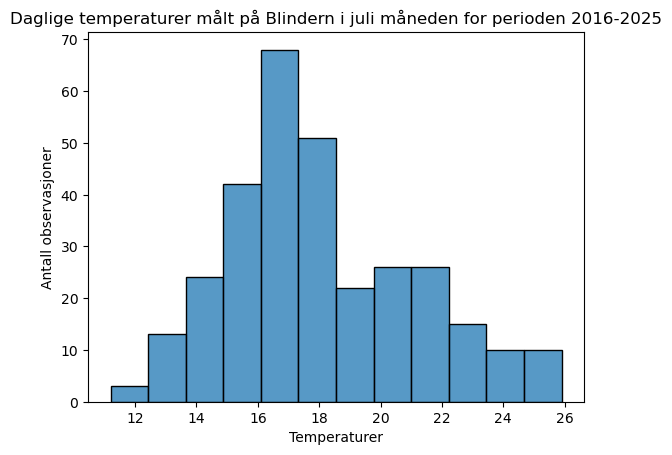

In [26]:
# En ordbok som skal holde datasettet vi laster inn.
data = {'dato':[], 'temp':[]}

with open('blindern_daily2016-2025.txt', 'r') as f:
    for linje in f:
        if linje.startswith('"day"'): # Går forbi den første linjen med kolnnenavn.
            continue
        else:
            linje = linje.strip()
            linje_biter = linje.split(';')
            # Formaterer datoene og legger inn i ordboken.
            data['dato'].append(str(linje_biter[0]) + "/" + str(linje_biter[1]) + "-" + str(linje_biter[2]))
            # Legger inn temperaturene i ordboken.
            data['temp'].append(float(linje_biter[3]))

df1 = pd.DataFrame(data) # Oppretter en Pandas dataframe av ordboken.

# Plotter histogrammet.
sns.histplot(x=df1['temp'])
plt.title("Daglige temperaturer målt på Blindern i juli måneden for perioden 2016-2025")
plt.xlabel("Temperaturer")
plt.ylabel("Antall observasjoner")
plt.show()

Fra histogrammet er det mulig å se at de fleste observasjonene har målt temperaturen rundt 17-18 grader i juli måneden for perioden 2016-2025. Derfor kan vi tenke at gjennomsnittet mest sannsynlig ligger også nærme de verdiene. I tillegg er det mulig å se at fordelingen er lett høyreskjev (de fleste observasjonene ligger på venstre siden av diagrammet) - temperaturene var som vanlig noe under 17-18 grader enn over det intervallet i juli måneden i årene fra 2016-2025.

### b) Gi en oppsummering av dataene ved å bruke både sentralmål (gjennomsnitt og median) ogspredningsmål (standardavvik og interkvartilavstand). Hva er disse tallene uttrykk for og hva kan du konkludere om dataene basert på disse målene?

In [27]:
# Formatert utskrift av sentral- og spredningsmål i datasettet. 
print(f'Sentralmål:\n-gjennomsnitt: {df1['temp'].mean(): .2f};\n-median: {df1['temp'].median(): .2f}.')
print(f'\nSpredningsmål:\n-standardavvik: {df1['temp'].std(): .2f};\n'
      f'-interkvartilavstand (IQR): {df1['temp'].quantile(0.75) - df1['temp'].quantile(0.25)}.')

Sentralmål:
-gjennomsnitt:  18.04;
-median:  17.50.

Spredningsmål:
-standardavvik:  3.07;
-interkvartilavstand (IQR): 4.25.


Sentralmål - uttrykk for hvordan dataene våre grupperer seg; forteller oss hva som er vanligste eller typiske verdier/målinger i vårt datasett. Spredningsmål - viser hvordan og hvor mye datapunktene avviker/varierer fra det som er vanlig eller typisk (sentralmålene); de viser spredningen av frekvensene i datamaterialet og om spredningen er høyre-/venstreskjev eller symmetrisk. Veldig lite varians/standardavvik - datapunktene er tett gruppert rundt gjennomsnittet; stor varians/standardavvik - datapunktene er ganske spredt ut over grafen.

Fra sentralmålene kan vi også se at frekvensfordelingen for temperaturmålene er lett høyreskjev (gjennomsnittet er noe høyere enn medianen) til symmetrisk (forskjellen er ikke så stor - 0.54). Standardavviket viser variasjon på ca. 3 grader fra gjennomsnittet, som vil si temperaturene var som vanlig i området fra ca 15-21 grader i juli fra 2016-2025. IQR-en, som er noe mer robust spredningsmål i der man har skjeve frekvensfordelinger sånn som det er i vårt tilfellet, har høyere verdi - 4.25 - så 1.20 grader høyere variasjon i temperaturene, i intervallet fra litt under 14 grader til ca 22.5. 

### c) Del datasettet opp i to og sammenligne datene fra 2018 og 2025 med dataene fra de andre åtteårene i denne tidsperioden. Hvor mange dager i juli 2018 og 2025 har målt døgntemperatur over 20∘C? Hvor ofte er det målt døgntemperatur over 20∘C i juli de andre åtte årene? Hva sier dette om sommerene 2018 og 2025?

In [28]:
df_2018 = df.set_index('dato').loc['1/7-2018' : '31/7-2018'] # Deler opp datasettene. 
df_2025 = df.set_index('dato').loc['1/7-2025' : '31/7-2025']

ant_dager_over_20_2018 = len(df_2018.query('temp > 20')) # Teller opp antall dager med 'temp > 20'.
ant_dager_over_20_2025 = len(df_2025.query('temp > 20'))

print(f"\nAntall dager med temperaturen over 20 grader i juli 2018: {ant_dager_over_20_2018}.")
print(f"Antall dager med temperaturen over 20 grader i juli 2025: {ant_dager_over_20_2025}.")

# Slår sammen resterende år (unntatt 2018 og 2025).
df_resterende_år = pd.concat([df.set_index('dato').loc['1/7-2016' : '31/7-2017'].reset_index(), df.set_index('dato').loc['1/7-2019' : '31/7-2024'].reset_index()], ignore_index=True)

# Teller hvor mange dager det var over 20 grader i hele datasettet uten 2018 og 2025.
ant_dager_over_20_resterende_år = len(df_resterende_år.query('temp > 20'))

# Regner ut gjennomsnittet for de 8 årene.
gjennomsn_resterende_år = ant_dager_over_20_resterende_år / 8

# Printer ut resultatet.
print(f"Totalt antall dager med temperaturen over 20 grader i juni for årene unntatt 2018 og 2025:" 
      f" {ant_dager_over_20_resterende_år}.\n"
      f"Dette gir {gjennomsn_resterende_år} dager med temperatur over 20 grader" 
      f" i juli i gjennomsnittet for hvert år unntatt 2018 og 2025.")


Antall dager med temperaturen over 20 grader i juli 2018: 29.
Antall dager med temperaturen over 20 grader i juli 2025: 17.
Totalt antall dager med temperaturen over 20 grader i juni for årene unntatt 2018 og 2025: 34.
Dette gir 4.25 dager med temperatur over 20 grader i juli i gjennomsnittet for hvert år unntatt 2018 og 2025.


Vi kan se at antallet dager med temperatur over 20 grader i juli for perioden 2016-2025 unntatt årene 2018 og 2025 er bare 34, mens antallet dager med temperatur over 20 grader for 2018 og 2025 er henholdsvis 29 og 17. Dette sier til oss at juli i 2018 og 2025 har vært samlet sett mye varmere enn andre år i den tiårs perioden.

### d) Bruk data visualiseringer og oppsummerende mål til å sammenligne de to datasettene. Hva kan du konkludere om forskjellen på temperaturen i julimåned på Blindern i de to tidsperiodene?

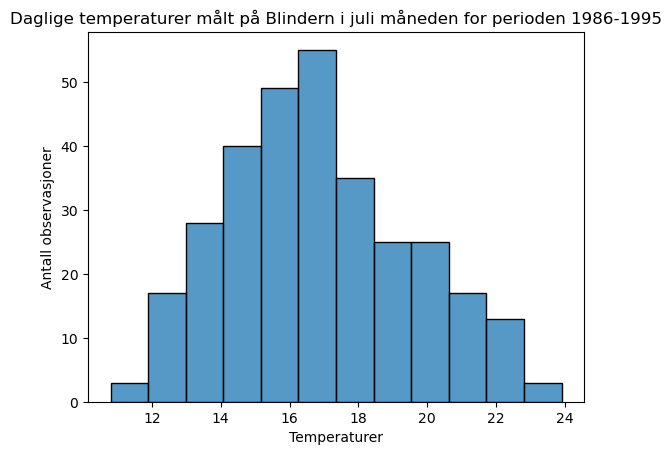

In [29]:
data = {'dato':[], 'temp':[]}

with open('blindern_daily1986-1995.txt', 'r') as f:
    for linje in f:
        linje = linje.strip()
        linje_biter = linje.split(';')
        # Try/except blokken under håndterer den første linje i txt-filen. 
        # Av en ukjent grunn var det ikke mulig å benytte meg av samme koden som 
        # i tilfellet med det første datasettet. 
        try:
            temp = float(linje_biter[3])
        except:
            continue
        data['dato'].append(str(linje_biter[0]) + "/" + str(linje_biter[1]) + "-" + str(linje_biter[2]))
        data['temp'].append(temp)

df2 = pd.DataFrame(data)

sns.histplot(x=df2['temp'])
plt.title("Daglige temperaturer målt på Blindern i juli måneden for perioden 1986-1995")
plt.xlabel("Temperaturer")
plt.ylabel("Antall observasjoner")
plt.show()

Fra plottet kan vi se at temperaturverdiene er forskjøvet litt nedover på temperaturskalaen. Det er mulig å finne gjennomsnittet på ca 16-17 grader, men også kan man se at frekvensfordelingen for denne tiårsperioden også er lett høyreskjev. 

In [30]:
print(f"\nSentralmål (datasettet 1986-1995):\n"
      f"-gjennomsnitt: {df2['temp'].mean(): .2f};\n"
      f"-median: {df2['temp'].median(): .2f}.")
print(f"\nSpredningsmål (datasettet 1986-1995):\n"
      f"-standardavvik: {df2['temp'].std(): .2f};\n"
      f"-IQR: {df['temp'].quantile(0.75) - df['temp'].quantile(0.25)}.")


Sentralmål (datasettet 1986-1995):
-gjennomsnitt:  16.86;
-median:  16.60.

Spredningsmål (datasettet 1986-1995):
-standardavvik:  2.69;
-IQR: 4.25.


Gjennomsnittet for årene 1986-1995 ligger på 16.86, mens medianen er på 16.60 (gjennomsnittet > medianen - passer fint med den ovenfor observerte høyreskjevhet). Forskjellen mellom gjennomsnitte og medianen er også noe mindre i dette datasettet, som kan tyde på noe mer balanserte datapunktene her. Vi kan se et standard avviket også er noe mindre som passert fint sammen med at medianen og gjennomsnitte avviker ikke så mye fra hverandre. Vi kan da si at temperaturen i juli månedene i årene 1986-1995 har vanligst vært i intervallet mellom ca litt under 14 grader til ca 19.5 grader (iflg standardavviket) eller evt. fra ca 14 grader til ca 21 grader ifgl IQR verdien, som kanskje igjen her på grunn av lett skjevhet til høyre i datapunktene burde helst tas i betraktning. Dette betyr at totalt sett var juli måneden noen grader kaldere i perioden 1986-1995 enn i perioden 2016-2025. 

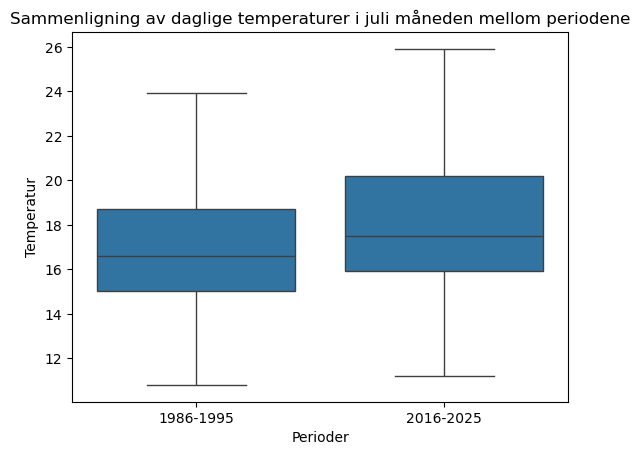

In [31]:
df1["periode"] = "2016-2025" # Legger til kolonnene med perioder i datasettene.
df2["periode"] = "1986-1995"

df_sammenslått = pd.concat([df2, df1], ignore_index=True) # Sammenslår datasettene.

sns.boxplot(x="periode", y="temp", data=df_sammenslått)
plt.title("Sammenligning av daglige temperaturer i juli måneden mellom periodene")
plt.xlabel("Perioder")
plt.ylabel("Temperatur")
plt.show()

Boksplottene viser veldig tydelig det som er diskutert ovenfor.

### e) Finnes det noen år i den første tidsperioden (1986-1995) hvor julimåned var varmere enn normalt på Blindern? Hvis ja, hvordan var temperaturen dette året/disse årene sammenlignet med 2018 og 2025?

In [32]:
år = [_ for _ in range(1986,1996)] # Oppretter en liste med år i perioden 1986-1995.
# Liste med antall dager med temp > 20 (antall har samme indeks som årene de hører til).
ant_dager_over_20 = list()
# En liste å holde år som er varmere enn 2018.
varmere_enn_2018 = list()
# En liste å holde år som er varmere enn 2025.
varmere_enn_2025 = list()
# En liste å holde antallet dager med temp > 20 til året/årene varmere enn 2018.
ant_1 = list()
# En liste å holde antallet dager med temp > 20 til året/årene varmere enn 2025.
ant_2 = list()

# Teller antall dager med temp > 20 for hvert år.
for i in range(0, 279, 31):
    ant_dager_over_20.append(len(df2.iloc[i:i+31].query('temp > 20')))

# Finner år som er henholdvis varmere enn 2018 og 2025.
for ant in ant_dager_over_20:
    if ant > 29:
        varmere_enn_2018.append(år[ant_dager_over_20.index(ant)])
        ant_1.append(ant)
    elif ant > 17:
        varmere_enn_2025.append(år[ant_dager_over_20.index(ant)])
        ant_2.append(ant)

# Skriver ut året/årene varmere enn 2018 (hvis de finns).
if varmere_enn_2018:
    print("Året/årene som var varmere enn 2018 i perioden 1986-1995 (antall dager med temperatur over 20 grader i juli):")
    for år in varmere_enn_2018:
        for ant in ant_1:
            print(f"- {år}, {ant} dager;")
else:
    print("Ingen av årene i perioden 1986-1995 var varmere enn 2018.")

# Skriver ut året/årene varmere en 2025 (hvis de finns)
if varmere_enn_2025:
    print("\nÅret/årene som var varmere enn 2025 i perioden 1986-1995 (antall dager med temperatur over 20 grader i juli):")
    for år in varmere_enn_2025:
        for ant in ant_2:
            print(f"- {år}, {ant} dager;")
else:
    print("\nIngen av årene i perioden 1986-1995 var varmere enn 2025.")

Ingen av årene i perioden 1986-1995 var varmere enn 2018.

Året/årene som var varmere enn 2025 i perioden 1986-1995 (antall dager med temperatur over 20 grader i juli):
- 1994, 19 dager;


1994 hadde totalt 19 dager med temperatur over 20 grader, som gjør det året varmere enn 2025 med 2 dager med temperaturen over enn 20 grader flere enn 2025. Det forsatt betyr at året 2018 var det varmeste utfra de to observerte periodene, hvis det er antallet dager med temperatur over 20 grader vi ser på.

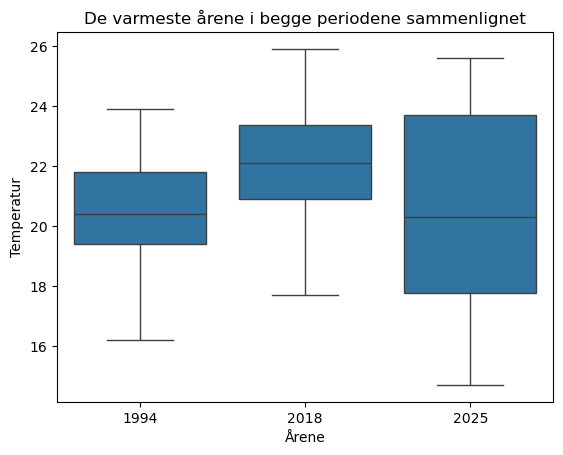

In [33]:
df_94 = df2.set_index('dato').loc['01/07-1994' : '31/07-1994'] # Lager dataframe for året 1994.
df_94 = df_94.reset_index()

df_94["periode"] = "1994" # Legger inn 'periode-taggene'.
df_2018["periode"] = "2018"
df_2025["periode"] = "2025"

# Sammenslår disse tre datasettene så at det kan lages et boksplott som kan sammenligne temperaturene i dem.
df_94_18_25 = pd.concat([df_94, df_2018, df_2025], ignore_index=True) 

# Lager boksplottet for å sammenligne disse tre årene.
sns.boxplot(x="periode", y="temp", data=df_94_18_25)
plt.title("De varmeste årene i begge periodene sammenlignet")
plt.xlabel("Årene")
plt.ylabel("Temperatur")
plt.show()

Det er mulig å se fra boksplottet over at året 2018 forblir det varmeste året ut fra de 2 periodene vi har sett på. Medianen ligger på litt over 22 grader og temperaturene har variert veldig lite fra den i 2018 (hele 29 dager ut fra 31 med temperatur over 20 grader, som sett ovenfor; all variasjon er over 20 grader). 
2025 blir det "kaldeste" av disse tre årene sånt sett. Medianen var nesten like høy som i 1994, men 2025 hadde my mer variasjon i temperaturene, og mye som var under 20 grader, samt den minimale temperaturen var mye lavere enn i både 1994 og 2018. 